# Exp 2 · XGBoost — Regularisation + Early Stopping
**Week 6**

Baseline problem: train/test MAPE gaps of **+95.7%** (inventory) and **+60.2%** (order velocity).

Fix: stronger regularisation + temporal early stopping on a held-out val split.

Model file: `models/xgboost_model_v2.py`

In [1]:
import os, sys, warnings
if os.path.basename(os.getcwd()) == 'week6': os.chdir('../..')
elif os.path.basename(os.getcwd()) == 'notebooks': os.chdir('..')
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams.update({'figure.figsize': (13, 4), 'axes.spines.top': False, 'axes.spines.right': False})

TARGETS = ['label_inventory_delta','label_cashflow_delta','label_order_velocity_delta']
SHORT   = {'label_inventory_delta':'Inventory','label_cashflow_delta':'Cash Flow','label_order_velocity_delta':'Order Velocity'}
# Baseline numbers (hard-coded from baseline_report.ipynb — do not recompute)
BASELINE = {
    'label_inventory_delta':      {'mape': 123.4, 'picp': 0.681, 'nmpiw': 0.200},
    'label_cashflow_delta':       {'mape':  90.9, 'picp': 0.754, 'nmpiw': 0.367},
    'label_order_velocity_delta': {'mape':  90.5, 'picp': 0.697, 'nmpiw': 0.536},
}  # XGBoost v1 on 80/20 temporal split
from models.xgboost_model    import (load_features, temporal_split,
    train_xgboost as train_v1, get_X_y, mape as _mape)
from models.xgboost_model_v2 import train_xgboost as train_v2
from evaluation.metrics import evaluate_all_models, print_metrics_table

PARAM_TABLE = {
    'min_child_weight': ('5',    '15'),
    'max_depth':        ('5',    '4'),
    'reg_alpha':        ('0',    '0.1'),
    'reg_lambda':       ('1.0',  '2.0'),
    'n_estimators':     ('300',  '500 (ceiling; early-stopped)'),
    'early_stopping':   ('none', '30 rounds on temporal val'),
}
print(f"{'Parameter':<22}  {'v1 (baseline)':>18}  {'v2':>30}")
print('-'*74)
for k, (v1, v2) in PARAM_TABLE.items():
    print(f"  {k:<20}  {v1:>18}  {v2:>30}")


Parameter                    v1 (baseline)                              v2
--------------------------------------------------------------------------
  min_child_weight                       5                              15
  max_depth                              5                               4
  reg_alpha                              0                             0.1
  reg_lambda                           1.0                             2.0
  n_estimators                         300    500 (ceiling; early-stopped)
  early_stopping                      none       30 rounds on temporal val


In [2]:
df = load_features('data/processed/training_data.csv')
train, test = temporal_split(df)

print('\n=== XGBoost v1 (baseline) ===')
v1 = train_v1(train, test)

print('\n=== XGBoost v2 (regularised + early stopping) ===')
v2 = train_v2(train, test)


Loaded 2,100 rows from data/processed/training_data.csv
  Date range: 2025-11-30 → 2026-08-17
  Businesses: 150
  Branches:   2,100

Temporal split at 2026-06-26 (80%/20%)
  Train rows: 1,677  |  Test rows: 423

=== XGBoost v1 (baseline) ===

Training: inventory
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: cashflow
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: order_velocity
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

=== XGBoost v2 (regularised + early stopping) ===

Early-stopping val split: 1,425 model rows | 252 val rows

Training: inventory
  point model: early stopped at 115 trees  (val RMSE=18.4986)
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: cashflow
  point model: early stopped at 246 trees  (val RMSE=1415.5042)
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: order_velocity
  point model: early stopped at 104 trees  (val RMS

## Train vs test MAPE gap — overfitting check

,v1 train,v1 test,v1 gap,v2 train,v2 test,v2 gap
Target,,,,,,
Inventory,27.7,123.4,95.7,44.7,86.2,41.5
Cash Flow,74.3,90.9,16.6,93.9,102.0,8.1
Order Velocity,30.3,90.5,60.2,54.4,89.9,35.5


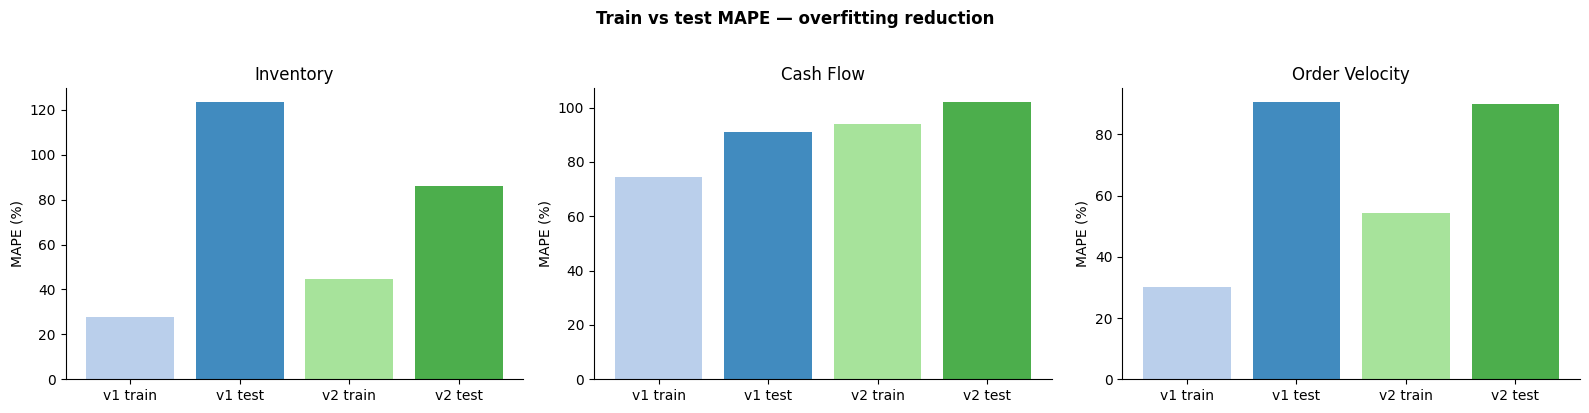

In [3]:
def get_train_mape(results, train_df, target):
    feat = results[target]['feature_cols']
    X_tr = train_df[feat].fillna(0).astype(float)
    y_tr = train_df[target].astype(float).values
    return _mape(y_tr, results[target]['model_point'].predict(X_tr))

rows = []
for target in TARGETS:
    v1_tr = get_train_mape(v1, train, target)
    v2_tr = get_train_mape(v2, train, target)
    rows.append({
        'Target':       SHORT[target],
        'v1 train':     round(v1_tr, 1),
        'v1 test':      round(v1[target]['mape'], 1),
        'v1 gap':       round(v1[target]['mape'] - v1_tr, 1),
        'v2 train':     round(v2_tr, 1),
        'v2 test':      round(v2[target]['mape'], 1),
        'v2 gap':       round(v2[target]['mape'] - v2_tr, 1),
    })
gap_df = pd.DataFrame(rows).set_index('Target')
display(gap_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, target in zip(axes, TARGETS):
    row   = gap_df.loc[SHORT[target]]
    names = ['v1 train', 'v1 test', 'v2 train', 'v2 test']
    vals  = [row['v1 train'], row['v1 test'], row['v2 train'], row['v2 test']]
    colors = ['#aec7e8','#1f77b4','#98df8a','#2ca02c']
    ax.bar(names, vals, color=colors, alpha=0.85)
    ax.set_ylabel('MAPE (%)'); ax.set_title(SHORT[target])
plt.suptitle('Train vs test MAPE — overfitting reduction', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


## Full metrics comparison

In [4]:
ev = evaluate_all_models({'XGBoost v1': v1, 'XGBoost v2': v2})
print_metrics_table(ev)



MAPE (%)
Model           XGBoost v1  XGBoost v2
Target                                
Cash Flow             90.9       102.0
Inventory            123.4        86.2
Order Velocity        90.5        89.9

RMSE
Model           XGBoost v1  XGBoost v2
Target                                
Cash Flow          1029.04     1007.39
Inventory            20.82       20.69
Order Velocity        4.08        4.05

PICP
  (target: 0.8)
Model           XGBoost v1  XGBoost v2
Target                                
Cash Flow            0.754       0.759
Inventory            0.681       0.799
Order Velocity       0.697       0.778

MPIW
Model           XGBoost v1  XGBoost v2
Target                                
Cash Flow          2355.10     2669.87
Inventory            22.88       53.82
Order Velocity        7.56        9.73

NMPIW
Model           XGBoost v1  XGBoost v2
Target                                
Cash Flow            0.367       0.416
Inventory            0.200       0.469
Order Velocit

## Early stopping — how many trees did each target use?

In [5]:
print('Best iteration per target (v2):')
for target in TARGETS:
    n = v2[target]['best_n_trees']
    print(f'  {SHORT[target]:<18}  {n} trees  (ceiling was 500)')


Best iteration per target (v2):
  Inventory           115 trees  (ceiling was 500)
  Cash Flow           246 trees  (ceiling was 500)
  Order Velocity      104 trees  (ceiling was 500)


## Pass / Fail

In [6]:
print('PASS/FAIL — v2 inventory train/test gap < 50% (down from 95.7%)')
for target in TARGETS:
    feat = v2[target]['feature_cols']
    X_tr = train[feat].fillna(0).astype(float)
    y_tr = train[target].astype(float).values
    tr_mape = _mape(y_tr, v2[target]['model_point'].predict(X_tr))
    gap  = v2[target]['mape'] - tr_mape
    flag = 'PASS ✓' if (target == 'label_inventory_delta' and gap < 50) or target != 'label_inventory_delta' else 'FAIL ✗'
    print(f'  {SHORT[target]:<18}  gap={gap:+.1f}%  {flag}')


PASS/FAIL — v2 inventory train/test gap < 50% (down from 95.7%)
  Inventory           gap=+41.5%  PASS ✓
  Cash Flow           gap=+8.1%  PASS ✓
  Order Velocity      gap=+35.5%  PASS ✓
